<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/dnn-course-2026-1/blob/main/C1_M3_Lab_data_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Gerenciamento de Dados

Em laboratórios anteriores, você se concentrou em construir e treinar modelos com dados bem estruturados. No entanto, no mundo real, os dados raramente são perfeitos. Mesmo a arquitetura de modelo mais poderosa pode falhar se receber um fluxo de dados desorganizado, ineficiente ou não confiável. É aqui que um **pipeline de dados** robusto se torna essencial.

Este laboratório muda o seu foco do modelo para os dados em si, enfrentando os desafios comuns dos conjuntos de dados do mundo real. Você trabalhará com o conjunto de dados **[Oxford 102 Flowers](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/)**, uma coleção de imagens e rótulos armazenados em arquivos separados, com formatação inconsistente e possivelmente até com algumas amostras corrompidas. Para superar esses obstáculos, você usará as ferramentas de gerenciamento de dados essenciais do PyTorch: as classes **`Dataset`** e **`DataLoader`**.

Neste laboratório, você vai:

* Explorar um conjunto de dados do mundo real com arquivos desorganizados e rótulos separados.
* Construir um **`Dataset`** personalizado do PyTorch para carregar e pré-processar imagens e rótulos dinamicamente (*on the fly*).
* Aplicar **transformações** e **aumento de dados** (*data augmentation*) para preparar seus dados e melhorar a robustez do modelo.
* Usar o **`DataLoader`** para criar e embaralhar lotes (*batches*) de forma eficiente para o treinamento.
* Dividir seus dados em conjuntos de treinamento, validação e teste.
* Implementar técnicas de tratamento de erros para gerenciar problemas nos dados e monitorar o desempenho do seu pipeline.

## Importação de bibliotecas

In [1]:
# Bibliotecas padrão do Python para sistema operacional e manipulação de arquivos compactados
import os
import tarfile

# Biblioteca para plotagem de gráficos, curvas de perda/acurácia e visualização de imagens
import matplotlib.pyplot as plt

# Biblioteca fundamental para computação científica e manipulação de matrizes/vetores
import numpy as np

# Biblioteca para realizar requisições HTTP (como baixar datasets da internet)
import requests

# Biblioteca para funções matemáticas avançadas e processamento de sinais/imagens
import scipy

# Biblioteca padrão para processamento de imagens (abrir, salvar e manipular formatos)
from PIL import Image

# Componentes do PyTorch para gerenciamento de dados: criação de datasets customizados,
# criação de subconjuntos, divisão aleatória (treino/validação) e carregadores de lotes (batches)
from torch.utils.data import Dataset, Subset, random_split, DataLoader

# Módulo do PyTorch focado em transformações e aumentos de dados (Data Augmentation) em imagens
from torchvision import transforms

# Biblioteca utilizada para exibir barras de progresso interativas durante loops e treinamentos
from tqdm.auto import tqdm

# Módulo utilitário local customizado (específico para este projeto/laboratório)
import helper_utils_5

## Baixar arquivos auxiliares

In [2]:
import os

def download_files(filenames):
    """
    Baixa uma lista de arquivos do repositório do curso se eles não existirem localmente.
    """
    # URL base do repositório remoto onde os arquivos do curso estão hospedados
    base_url = "https://raw.githubusercontent.com/fabiobento/dnn-course-2026-1/main/"
    
    # Itera sobre cada nome de arquivo presente na lista fornecida
    for filename in filenames:
        # Verifica se o arquivo já existe no diretório local para evitar downloads duplicados
        if not os.path.exists(filename):
            # Monta a URL completa combinando o endereço base com o nome do arquivo
            url = f"{base_url}{filename}"
            print(f"Baixando {filename}...")
            
            # Executa uma chamada de sistema utilizando o comando 'wget'
            # A flag '-q' ativa o modo silencioso (quiet) e '-O' define o nome do arquivo de saída
            os.system(f"wget -q {url} -O {filename}")
        else:
            # Caso o arquivo já esteja presente, o script apenas notifica o usuário e pula para o próximo
            print(f"O arquivo '{filename}' já existe localmente. Pulando...")

# Lista com os arquivos auxiliares essenciais para a execução correta deste notebook:
arquivos_necessários = [
    'helper_utils_5.py',           # Script local com funções utilitárias de suporte
    'corrupted_flower_data.tar.gz', # Dataset compactado que será utilizado nas práticas
]

# Dispara a função para garantir que todos os dependências estejam disponíveis no ambiente local
download_files(arquivos_necessários)

O arquivo 'helper_utils_5.py' já existe localmente. Pulando...
O arquivo 'corrupted_flower_data.tar.gz' já existe localmente. Pulando...


In [3]:
# Descompacta o arquivo do dataset 'corrupted_flower_data.tar.gz' 
# -x: extrai os arquivos
# -z: descompacta o formato gzip
# -f: especifica o nome do arquivo a ser tratado
!tar -xzf corrupted_flower_data.tar.gz

## Acesso aos Dados

Todo projeto de *deep learning* começa com dados, mas nem todos os dados estão prontos para uso. Às vezes eles já estão bem organizados, mas frequentemente estão dispersos ou armazenados em formatos que não são diretamente compatíveis com o treinamento de modelos.

Nesta seção, você aprenderá a gerenciar o acesso aos dados e a seguir as melhores práticas para trabalhar com conjuntos de dados desorganizados ou inconsistentes.

### Exploração do Conjunto de Dados

O primeiro passo ao trabalhar com um novo conjunto de dados é acessar e explorar sua estrutura. Isso ajuda você a entender como os dados estão organizados e, portanto, como carregá-los e utilizá-los de maneira eficaz.

* Você definirá uma função `download_dataset` que baixa o conjunto de dados de uma determinada URL e o extrai para um diretório especificado.
* Neste caso, o conjunto de dados consiste em dois arquivos: um arquivo `.tgz` com as imagens e um arquivo `.mat` contendo os rótulos.

Ambos os arquivos serão baixados usando a biblioteca `requests` e, em seguida, extraídos usando a biblioteca `tarfile`.

In [4]:
def download_dataset():
    """
    Baixa e extrai um dataset a partir de URLs remotas se ele já não estiver presente localmente.

    Esta função primeiro verifica a existência dos arquivos do dataset em um diretório
    específico. Se os arquivos não forem encontrados, ela faz o download a partir de
    URLs predefinidas e, em seguida, extrai o conteúdo.
    """
    # Define o diretório onde o dataset será armazenado.
    data_dir = "flower_data"
    
    # Define os caminhos para pastas e arquivos essenciais.
    image_folder_path = os.path.join(data_dir, "jpg")
    labels_file_path = os.path.join(data_dir, "imagelabels.mat")
    tgz_path = os.path.join(data_dir, "102flowers.tgz")

    # Verifica se a pasta principal de dados e o arquivo de rótulos (labels) já existem.
    if os.path.exists(image_folder_path) and os.path.exists(labels_file_path):
        # Informa ao usuário que o dataset já está disponível localmente e cancela o download.
        print(f"O dataset já existe. Carregando localmente a partir de '{data_dir}'.")
        # Encerra a função, já que nenhum download é necessário.
        return

    # Informa ao usuário que o dataset não foi encontrado e que o download vai começar.
    print("Dataset não encontrado localmente. Iniciando download...")

    # Define as URLs para o arquivo compactado das imagens e para o arquivo de rótulos.
    image_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz"
    labels_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat"

    # Cria o diretório de destino para o dataset, caso ele ainda não exista.
    os.makedirs(data_dir, exist_ok=True)

    # Anuncia o início do processo de download das imagens.
    print("Baixando imagens...")
    # Envia uma requisição HTTP GET para a URL da imagem, habilitando streaming para arquivos grandes.
    response = requests.get(image_url, stream=True)
    # Obtém o tamanho total do arquivo a partir dos cabeçalhos de resposta para a barra de progresso.
    total_size = int(response.headers.get("content-length", 0))

    # Abre um arquivo local no modo de escrita binária para salvar o pacote baixado.
    with open(tgz_path, "wb") as file:
        # Itera sobre o conteúdo da resposta em pedaços (chunks) junto com uma barra de progresso.
        for data in tqdm(
            # Define o tamanho do pedaço para iterar sobre o conteúdo.
            response.iter_content(chunk_size=1024),
            # Define o total para a barra de progresso com base no tamanho do arquivo em kilobytes.
            total=total_size // 1024,
        ):
            # Escreve cada pedaço de dados no arquivo local.
            file.write(data)

    # Anuncia o início do processo de extração do arquivo.
    print("Extraindo arquivos...")
    # Abre o arquivo tar.gz baixado no modo de leitura.
    with tarfile.open(tgz_path, "r:gz") as tar:
        # Extrai todo o conteúdo do arquivo compactado dentro do diretório de destino.
        tar.extractall(data_dir)

    # Anuncia o início do download do arquivo de rótulos (labels).
    print("Baixando rótulos (labels)...")
    # Envia uma requisição HTTP GET para a URL dos rótulos.
    response = requests.get(labels_url)
    # Abre um arquivo local no modo de escrita binária para salvar os rótulos.
    with open(labels_file_path, "wb") as file:
        # Escreve todo o conteúdo recebido na resposta diretamente no arquivo.
        file.write(response.content)

    # Informa ao usuário que o download e a extração foram concluídos com sucesso.
    print(f"Dataset baixado e extraído com sucesso para '{data_dir}'.")

    # Lista contendo a descrição textual de cada uma das 102 classes de flores
    labels_description = [
        'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily',
        'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea',
        'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
        'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth',
        'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation',
        'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower',
        'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
        'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia',
        'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
        'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy',
        'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily',
        'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
        'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen ', 'watercress',
        'canna lily', 'hippeastrum ', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow',
        'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily'
    ]

    # Salva os nomes textuais das classes em ordem em um arquivo de texto estruturado
    with open(os.path.join(data_dir, "labels_description.txt"), "w") as f:
        for idx, label in enumerate(labels_description, start=1):
            f.write(f"{label}\n")

In [5]:
# Chama a função para baixar, extrair e preparar o dataset de flores.
download_dataset()

Dataset não encontrado localmente. Iniciando download...
Baixando imagens...


  0%|          | 0/336779 [00:00<?, ?it/s]

Extraindo arquivos...
Baixando rótulos (labels)...
Dataset baixado e extraído com sucesso para 'flower_data'.


In [6]:
# Define o caminho para o diretório raiz do dataset.
path_dataset = './flower_data'

# Exibe a estrutura de pastas do diretório do dataset até uma profundidade máxima de um nível.
helper_utils_5.print_data_folder_structure(path_dataset, max_depth=1)

flower_data/
├── 102flowers.tgz
├── imagelabels.mat
├── jpg/
└── labels_description.txt


Você pode ver que o conjunto de dados consiste em:

* Uma pasta `jpg` contendo imagens no formato JPEG
* Um arquivo `imagelabels.mat` que armazena os rótulos (formato MATLAB)
* Um arquivo `labels_description.txt` que descreve cada rótulo

Isso lhe dá uma noção clara de como o conjunto de dados está estruturado e com o que você estará trabalhando.

### Criando uma Classe Dataset Personalizada

Após baixar e explorar brevemente o conjunto de dados, o próximo passo é criar uma classe *dataset* personalizada que organize o acesso aos dados. O objetivo é recuperar as imagens e seus respectivos rótulos de forma consistente e eficiente para o treinamento do modelo.

Você criará uma classe `FlowerDataset` que herda de `torch.utils.data.Dataset`.
Uma classe *dataset* personalizada *deve* implementar os seguintes métodos:

> `__init__`: Inicializa o objeto do conjunto de dados.
> * Normalmente aceita o caminho dos dados e quaisquer transformações (*transforms*) a serem aplicadas.
> * Opcionalmente, carrega metadados ou rótulos associados aos dados.
> 
> 
> `__len__`: Retorna o número de amostras no conjunto de dados.
> `__getitem__`: Recupera uma única amostra com base em um índice.
> * Carrega a imagem e seu rótulo, aplica as transformações e os retorna.
> 
> 

Além disso, você definirá métodos auxiliares (*helper methods*) para deixar o código mais limpo e organizado:

> `load_and_correct_labels`: Carrega os rótulos das imagens a partir do arquivo .mat do MATLAB.
> * Utiliza `scipy.io.loadmat` para ler o arquivo e extrair a matriz (*array*) de rótulos.
> * Os rótulos são ajustados subtraindo 1, o que é necessário porque o MATLAB usa indexação baseada em 1, enquanto o Python usa indexação baseada em 0.
> * Essa correção evita erros de deslocamento por um (*off-by-one errors*) durante o treinamento e a avaliação.
> 
> 
> 
> 
> `retrieve_image`: Carrega uma imagem do disco a partir do seu índice `idx`.
> * Com base no `idx`, reconstrói o nome do arquivo e o caminho, abre a imagem usando a biblioteca Pillow, converte-a para o formato RGB (para garantir a consistência) e retorna o objeto da imagem.
> 
> 
> `get_label_description`: Dado um rótulo, retorna uma descrição legível por humanos a partir do arquivo de texto.

**Sobre o carregamento tardio (*lazy loading*)**:
As imagens não são carregadas todas de uma vez quando o objeto do *dataset* é criado.
Em vez disso, elas são carregadas dinamicamente (*on the fly*) quando acessadas através do método `__getitem__`.
Essa abordagem é eficiente em termos de memória, especialmente ao lidar com grandes conjuntos de dados, pois evita carregar todas as imagens na memória simultaneamente.

In [7]:
class FlowerDataset(Dataset):
    """
    Uma classe de dataset customizada para carregar dados de imagens.

    Esta classe foi projetada para funcionar com as abstrações Dataset e DataLoader
    do PyTorch. Ela gerencia o carregamento de imagens e seus respectivos rótulos
    (labels) a partir de uma estrutura de diretórios específica.
    """
    def __init__(self, root_dir, transform=None):
        """
        Inicializa o objeto do dataset.

        Args:
            root_dir (str): O diretório raiz onde o dataset está armazenado.
            transform (callable, opcional): Transformação opcional a ser aplicada
                em uma amostra.
        """
        # Armazena o caminho do diretório raiz.
        self.root_dir = root_dir
        # Armazena as transformações opcionais.
        self.transform = transform
        # Cria o caminho completo para o diretório de imagens.
        self.image_dir = os.path.join(self.root_dir, "jpg")
        # Carrega e processa os rótulos a partir do arquivo correspondente.
        self.labels = self.load_and_correct_labels()

    def __len__(self):
        """
        Retorna o número total de amostras no dataset.

        Returns:
            total_samples (int): O número total de itens no dataset.
        """
        # O número total de amostras é a quantidade de rótulos existentes.
        total_samples = len(self.labels)
        # Retorna o número total de amostras.
        return total_samples

    def __getitem__(self, idx):
        """
        Recupera uma amostra do dataset no índice especificado.

        Args:
            idx (int): O índice da amostra a ser recuperada.

        Returns:
            image (PIL.Image.Image ou torch.Tensor): Os dados da imagem processada.
            label (int): O rótulo correspondente para a imagem.
        """
        # Recupera a imagem para o índice fornecido.
        image = self.retrieve_image(idx)

        # Verifica se uma transformação foi fornecida.
        if self.transform is not None:
            # Aplica a transformação à imagem.
            image = self.transform(image)

        # Obtém o rótulo correspondente ao índice.
        label = self.labels[idx]

        # Retorna a imagem processada e seu respectivo rótulo.
        return image, label

    def retrieve_image(self, idx):
        """
        Carrega uma única imagem do disco com base no seu índice.

        Args:
            idx (int): O índice da imagem a ser carregada.

        Returns:
            image (PIL.Image.Image): A imagem carregada, convertida para RGB.
        """
        # Cria o nome do arquivo da imagem com base no índice (ex: image_00001.jpg).
        img_name = f"image_{idx + 1:05d}.jpg"
        # Cria o caminho completo para o arquivo de imagem.
        img_path = os.path.join(self.image_dir, img_name)
        # Abre o arquivo de imagem.
        with Image.open(img_path) as img:
            # Converte a imagem para o espaço de cores RGB.
            image = img.convert("RGB")
        # Retorna a imagem convertida.
        return image

    def load_and_correct_labels(self):
        """
        Carrega os rótulos de um arquivo e os ajusta para indexação baseada em zero.

        Returns:
            labels (numpy.ndarray): Um array de rótulos inteiros indexados em zero.
        """
        # Carrega o arquivo MATLAB contendo os rótulos.
        self.labels_mat = scipy.io.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extrai o array de rótulos e corrige para indexação baseada em zero (padrão Python).
        labels = self.labels_mat["labels"][0] - 1
        # Retorna os rótulos processados.
        return labels

    def get_label_description(self, label):
        """
        Recupera a descrição em texto para um determinado índice de rótulo.

        Args:
            label (int): O rótulo do tipo inteiro.

        Returns:
            description (str): A descrição textual correspondente do rótulo.
        """
        # Cria o caminho para o arquivo que contém as descrições dos rótulos.
        path_labels_description = os.path.join(self.root_dir, "labels_description.txt")
        # Abre o arquivo de descrição de rótulos para leitura.
        with open(path_labels_description, "r") as f:
            # Lê todas as linhas do arquivo.
            lines = f.readlines()
        # Obtém a descrição para o rótulo especificado e remove espaços extras no início/fim.
        description = lines[label].strip()
        # Retorna a descrição limpa.
        return description

In [8]:
# Inicializa o objeto do dataset, fornecendo o caminho para os dados.
dataset = FlowerDataset(path_dataset)

É uma boa prática verificar se a sua classe *dataset* funciona como esperado antes de utilizá-la para treinar um modelo.

Após criar uma instância da classe `FlowerDataset`, você irá:

* Verificar o número total de amostras no conjunto de dados usando a função `len()`.

In [9]:
# Imprime o número total de amostras presentes no dataset.
print(f'Número de amostras no dataset: {len(dataset)}')

Número de amostras no dataset: 8189


* Recuperar uma amostra específica usando um índice.

In [10]:
# Define o índice da amostra que deseja recuperar.
sel_idx = 10

# Recupera a imagem e o rótulo (label) correspondentes ao índice selecionado.
img, label = dataset[sel_idx]

- Inspecione o tamanho e rótulo da imagem.

In [11]:
# Cria uma string detalhando as dimensões (largura e altura) da imagem.
img_size_info = f"Tamanho da imagem: {img.size}"

# Imprime as informações de tamanho da imagem junto com o seu respectivo rótulo.
print(f'{img_size_info}, Rótulo: {label}')

Tamanho da imagem: (500, 748), Rótulo: 76


<br>

* Visualize a imagem utilizando a função auxiliar `plot_img`.

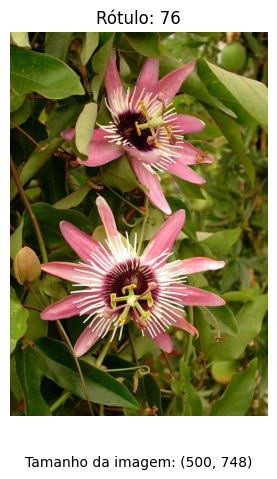

In [12]:
# Plota a imagem na tela, exibindo o rótulo como título e as dimensões como informação adicional.
helper_utils_5.plot_img(img, label=label, info=img_size_info)

Em seguida, inspecione os rótulos no conjunto de dados. Para cada rótulo único, imprima sua descrição correspondente usando o método `get_label_description`.

Como estão os rótulos?

In [13]:
# Obtém todos os rótulos (labels) do objeto do dataset.
dataset_labels = dataset.labels

# Cria um conjunto (set) de rótulos únicos para remover as duplicatas.
unique_labels = set(dataset_labels)

# Itera através de cada rótulo único.
for label in unique_labels:
    # Imprime o rótulo numérico e a sua descrição textual correspondente.
    print(f'Rótulo: {label}, Descrição: {dataset.get_label_description(label)}')

Rótulo: 0, Descrição: pink primrose
Rótulo: 1, Descrição: hard-leaved pocket orchid
Rótulo: 2, Descrição: canterbury bells
Rótulo: 3, Descrição: sweet pea
Rótulo: 4, Descrição: english marigold
Rótulo: 5, Descrição: tiger lily
Rótulo: 6, Descrição: moon orchid
Rótulo: 7, Descrição: bird of paradise
Rótulo: 8, Descrição: monkshood
Rótulo: 9, Descrição: globe thistle
Rótulo: 10, Descrição: snapdragon
Rótulo: 11, Descrição: colt's foot
Rótulo: 12, Descrição: king protea
Rótulo: 13, Descrição: spear thistle
Rótulo: 14, Descrição: yellow iris
Rótulo: 15, Descrição: globe-flower
Rótulo: 16, Descrição: purple coneflower
Rótulo: 17, Descrição: peruvian lily
Rótulo: 18, Descrição: balloon flower
Rótulo: 19, Descrição: giant white arum lily
Rótulo: 20, Descrição: fire lily
Rótulo: 21, Descrição: pincushion flower
Rótulo: 22, Descrição: fritillary
Rótulo: 23, Descrição: red ginger
Rótulo: 24, Descrição: grape hyacinth
Rótulo: 25, Descrição: corn poppy
Rótulo: 26, Descrição: prince of wales feathe

### Visão Geral das Imagens no Conjunto de Dados

Agora que você tem uma classe *dataset* funcional, você pode explorar as imagens no conjunto de dados. Você utilizará a função `visual_exploration` para visualizar algumas imagens e obter uma melhor compreensão dos dados.

In [14]:
def visual_exploration(dataset, num_rows=2, num_cols=4):
    """
    Exibe uma grade de amostras selecionadas aleatoriamente de um dataset para inspeção visual.

    Args:
        dataset (Dataset): O objeto do dataset de onde as amostras serão extraídas. Deve suportar
            indexação e possuir o método `get_label_description`.
        num_rows (int): O número de linhas na grade de exibição.
        num_cols (int): O número de colunas na grade de exibição.
    """
    # Calcula o número total de imagens a serem exibidas na grade.
    total_samples = num_rows * num_cols

    # Seleciona um conjunto aleatório de índices únicos a partir do dataset.
    indices = np.random.choice(len(dataset), total_samples, replace=False)

    # Cria uma grade de subplots para acomodar as imagens.
    fig, axes = helper_utils_5.get_grid(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 4))

    # Itera sobre cada eixo do subplot e o índice da amostra aleatória correspondente.
    for ax, idx in zip(axes.flatten(), indices):
        # Recupera a imagem e seu rótulo numérico a partir do dataset.
        image, label = dataset[idx]

        # Obtém a descrição textual legível por humanos para o rótulo.
        description = dataset.get_label_description(label)

        # Formata uma nova string de rótulo que inclui tanto o número quanto a descrição.
        label = f"{label} - {description}"

        # Cria uma string de informação com o índice da amostra e as dimensões da imagem.
        info = f"Índice: {idx} Tam: {image.size}"
        
        # Plota a imagem no subplot atual com seu respectivo rótulo e informações.
        helper_utils_5.plot_img(image, label=label, info=info, ax=ax)

    # Renderiza e exibe toda a grade de imagens na tela.
    plt.show()

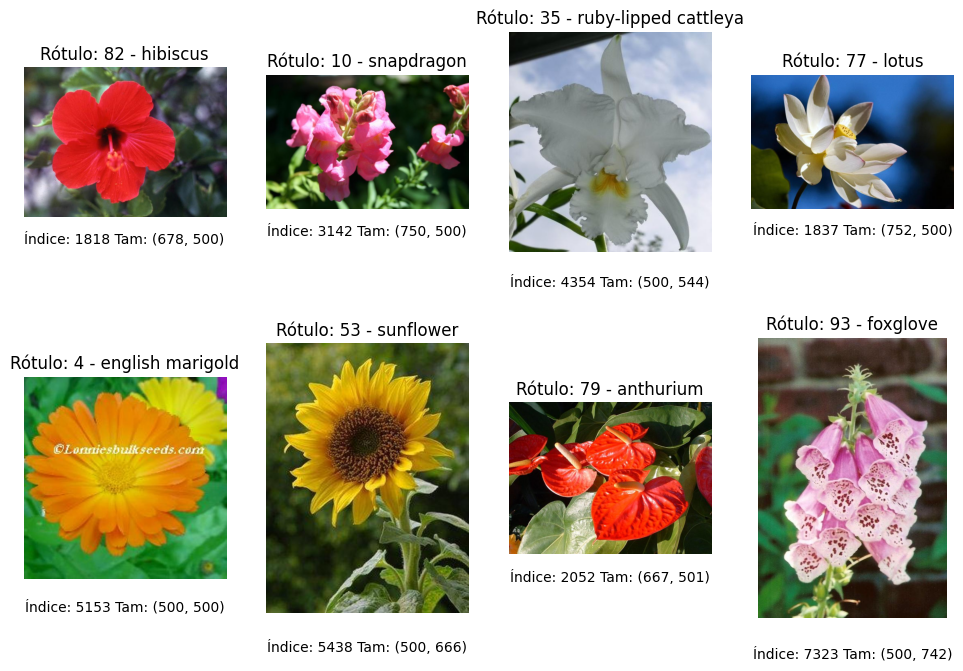

In [15]:
# Exibe uma grade 2x4 de amostras aleatórias do dataset para inspeção visual.
visual_exploration(dataset, num_rows=2, num_cols=4)

## Problemas de Qualidade

Como você viu na seção anterior, o tamanho das imagens no conjunto de dados varia significativamente. Isso pode ser um problema ao treinar um modelo, pois a maioria dos modelos espera que as imagens de entrada tenham o mesmo tamanho. Para resolver esse problema, você implementará uma série de transformações para padronizar o tamanho das imagens.

### Transformações

Após explorar o conjunto de dados e identificar potenciais problemas de qualidade, o próximo passo é aplicar transformações para pré-processar as imagens.
As transformações são operações que modificam as imagens para prepará-las para o treinamento do modelo. Exemplos comuns incluem redimensionamento (*resizing*), recorte (*cropping*), espelhamento (*flipping*) e normalização dos valores dos pixels.
O módulo `torchvision.transforms` fornece uma variedade de transformações pré-definidas que podem ser facilmente aplicadas às imagens.

Você começará definindo um pipeline de transformação simples composto por duas etapas:

Transformações **aplicadas diretamente às imagens brutas**:

* `Resize((256, 256))`: Redimensiona cada imagem para um tamanho fixo de 256x256 pixels.
* `CenterCrop(224)`: Recorta o centro da imagem para 224x224 pixels.

Transformações que **convertem e padronizam as imagens**:

* `ToTensor()`: Converte uma imagem PIL ou matriz NumPy em um tensor e dimensiona os valores dos pixels para o intervalo [0, 1].
* `Normalize(mean, std)`: Normaliza o tensor usando a média (*mean*) e o desvio padrão (*std*) especificados.

**Nota**:
A ordem das transformações frequentemente importa. O redimensionamento e o recorte devem ser aplicados antes de converter a imagem em um tensor.

In [16]:
# Define os valores médios (mean) para a normalização dos canais RGB.
mean = [0.485, 0.456, 0.406]
# Define os valores de desvio padrão (std) para a normalização dos canais RGB.
std = [0.229, 0.224, 0.225]

In [17]:
transform = transforms.Compose([
    # Transformações de imagem (PIL Image)
    transforms.Resize((256, 256)),  # Redimensiona as imagens para 256x256 pixels
    transforms.CenterCrop(224),     # Realiza um recorte centralizado (crop) para 224x224 pixels
    
    # Ponte para conversão em tensor
    transforms.ToTensor(),          # Converte as imagens para tensores do PyTorch (e escala para [0.0, 1.0])
    
    # Transformações aplicadas diretamente no tensor
    transforms.Normalize(mean=mean, std=std), # Normaliza o tensor utilizando a média e o desvio padrão definidos
])

Você criará agora uma nova instância da classe `FlowerDataset`, desta vez passando o pipeline de transformação `transform` como argumento.

In [18]:
# Cria uma nova instância do dataset aplicando as transformações de imagem especificadas.
dataset_transformed = FlowerDataset(path_dataset, transform=transform)

Inspecione a mesma amostra novamente para ver o efeito das transformações. Usando `quick_debug`, você pode ver que a imagem foi redimensionada e recortada para 224x224 pixels, e os valores dos seus pixels foram normalizados.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


Formato: torch.Size([3, 224, 224])
Tipo: torch.float32
Intervalo de valores de pixel: [-2.1, 2.6]


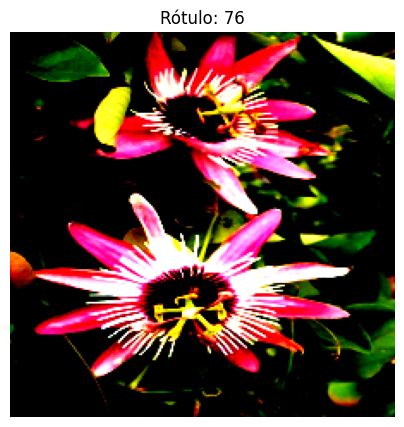

In [19]:
# Recupera a imagem transformada e o seu respectivo rótulo usando o mesmo índice selecionado.
img_transformed, label = dataset_transformed[sel_idx]

# Verificação rápida (depuração) das dimensões e valores do tensor
helper_utils_5.quick_debug(img_transformed)

# Plota a imagem após a aplicação das transformações
helper_utils_5.plot_img(img_transformed, label=label)

Observe que a imagem agora é um tensor com o formato `[3, 224, 224]`, representando 3 canais de cor (RGB) e 224x224 pixels. Como os valores dos pixels foram normalizados, eles não estão mais no intervalo original de [0, 255].

É por isso que a imagem parece diferente quando visualizada diretamente. Para exibi-la corretamente, você precisa *desnormalizá-la* primeiro. Você pode fazer isso aplicando a transformação `Normalize` novamente, usando os valores de `new_mean` e `new_std` para reverter o processo de normalização.

In [20]:
class Denormalize:
    """
    Uma classe invocável (callable) para reverter a normalização de uma imagem em formato de tensor.

    Esta classe calcula a transformação inversa de uma normalização padrão
    e pode ser usada como uma etapa de transformação, por exemplo, para visualizar imagens
    após terem sido normalizadas para um modelo.
    """
    def __init__(self, mean, std):
        """
        Inicializa a transformação de desnormalização.

        Args:
            mean (list ou tuple): Os valores de média utilizados na normalização original.
            std (list ou tuple): Os valores de desvio padrão utilizados na normalização original.
        """
        # Calcula a média ajustada para o processo de desnormalização.
        new_mean = [-m / s for m, s in zip(mean, std)]
        # Calcula o desvio padrão ajustado para o processo de desnormalização.
        new_std = [1 / s for s in std]
        # Cria um objeto de transformação Normalize com os parâmetros inversos.
        self.denormalize = transforms.Normalize(mean=new_mean, std=new_std)

    def __call__(self, tensor):
        """
        Aplica a transformação de desnormalização a um tensor.

        Args:
            tensor (torch.Tensor): O tensor normalizado que será desnormalizado.

        Returns:
            denormalized_tensor (torch.Tensor): O tensor desnormalizado.
        """
        # Aplica a transformação de desnormalização ao tensor de entrada.
        denormalized_tensor = self.denormalize(tensor)
        
        # Retorna o tensor desnormalizado.
        return denormalized_tensor

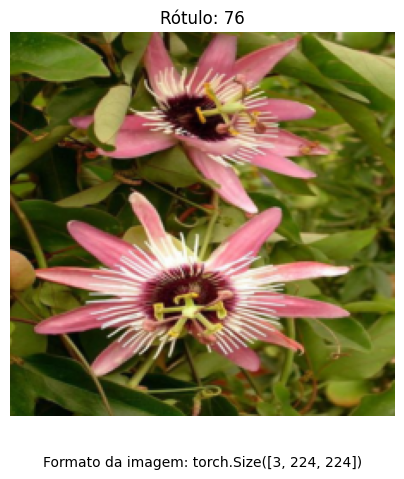

In [21]:
# Cria uma instância da classe Denormalize com a média (mean) e o desvio padrão (std) originais.
denormalize = Denormalize(mean=mean, std=std)
# Aplica a transformação de desnormalização ao tensor da imagem.
img_tensor = denormalize(img_transformed)

# Cria uma string informativa contendo o formato (shape) do tensor.
img_shape_info = f"Formato da imagem: {img_tensor.size()}"
# Plota a imagem desnormalizada para visualizar o resultado final.
helper_utils_5.plot_img(img_tensor, label=label, info=img_shape_info)

## Carregamento de Dados

Nesta seção, você aprenderá a preparar e fornecer dados de maneira eficiente para o treinamento de modelos no PyTorch. Um processo de treinamento completo normalmente inclui três etapas: treinamento, validação e avaliação.

Durante o treinamento, o modelo aprende com os dados de treino, ajustando seus pesos com base na função de perda.
Durante a validação, o modelo é avaliado em um conjunto de dados separado para ajustar hiperparâmetros e evitar o *overfitting*.
Durante a avaliação, o desempenho do modelo é testado em dados não vistos para avaliar sua capacidade de generalização.

Cada uma dessas etapas exige a divisão do conjunto de dados em subconjuntos distintos e o uso de carregadores de dados (*data loaders*) para fornecer as informações de forma eficiente durante o treinamento e os testes. A seguir, você verá como fazer isso usando o PyTorch.

### Dividindo o Conjunto de Dados

A função `split_dataset` dividirá o conjunto de dados em conjuntos de treinamento, validação e teste. Para fazer isso, você irá:

* Definir os tamanhos de cada subconjunto a partir das frações fornecidas para validação e teste.
* Utilizar a função `random_split` de `torch.utils.data` para realizar a divisão real.

In [22]:
def split_dataset(dataset, val_fraction=0.15, test_fraction=0.15):
    """
    Divide um dataset em conjuntos de treino, validação e teste.
    
    Por padrão, esta função particiona os dados em 70% para treino,
    15% para validação e 15% para teste.

    Args:
        dataset (torch.utils.data.Dataset): O dataset completo a ser dividido.
        val_fraction (float): A proporção do dataset a ser reservada para validação.
        test_fraction (float): A proporção do dataset a ser reservada para teste.

    Returns:
        train_dataset (torch.utils.data.Subset): A partição do dataset alocada para treino.
        val_dataset (torch.utils.data.Subset): A partição do dataset alocada para validação.
        test_dataset (torch.utils.data.Subset): A partição do dataset alocada para teste.
    """

    # Calcula o número total de itens no dataset.
    total_size = len(dataset)
    
    # Calcula a quantidade de itens para o conjunto de validação.
    val_size = int(total_size * val_fraction)
    
    # Calcula a quantidade de itens para o conjunto de teste.
    test_size = int(total_size * test_fraction)
    
    # Calcula a quantidade restante de itens para o conjunto de treino.
    train_size = total_size - val_size - test_size

    # Particiona o dataset com base nos tamanhos calculados.
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size]
    )
    
    # Retorna as partições resultantes do dataset.
    return train_dataset, val_dataset, test_dataset

#### Aplicando Transformações a Subconjuntos (*Subsets*)

Ao usar o `random_split`, cada divisão resultante é um objeto `Subset` que faz referência ao conjunto de dados original. Se o conjunto de dados original já possuir uma transformação, esses subconjuntos a herdarão e você não poderá atribuir uma transformação diferente diretamente.

Para lidar com isso corretamente, você irá:

1. Dividir o conjunto de dados **bruto** (sem transformações), de modo que cada subconjunto retorne imagens PIL puras.
2. Envolver cada subconjunto com a classe `SubsetWithTransform`, um invólucro (*wrapper*) leve que aplica uma transformação específica quando uma amostra é recuperada.

Esse padrão oferece controle total sobre qual transformação cada subconjunto utiliza e evita o problema de transformações serem aplicadas duas vezes.

In [23]:
class SubsetWithTransform(Dataset):
    """
    Um wrapper para um Subset do PyTorch que aplica uma transformação específica.

    Esta classe permite aplicar um conjunto diferente de transformações a um
    subconjunto de um dataset, o que é útil para criar conjuntos distintos de treino,
    validação ou teste com diferentes etapas de pré-processamento a partir do
    mesmo dataset base.
    """
    def __init__(self, subset, transform=None):
        """
        Inicializa o objeto SubsetWithTransform.

        Args:
            subset (torch.utils.data.Subset): Um objeto Subset do PyTorch contendo uma parte de um dataset.
            transform (callable, opcional): Uma transformação opcional a ser aplicada
                às amostras dentro deste subconjunto.
        """
        # Armazena o subconjunto original do dataset.
        self.subset = subset
        # Armazena as transformações a serem aplicadas.
        self.transform = transform

    def __len__(self):
        """
        Retorna o número total de amostras no subconjunto.

        Returns:
            subset_length (int): O número total de itens no subconjunto.
        """
        # Calcula o comprimento do subconjunto subjacente.
        subset_length = len(self.subset)
        # Retorna o comprimento calculado.
        return subset_length

    def __getitem__(self, idx):
        """
        Recupera uma amostra e aplica a transformação.

        Args:
            idx (int): O índice da amostra a ser recuperada.

        Returns:
            image (torch.Tensor ou PIL.Image.Image): A imagem transformada.
            label (int): O rótulo correspondente para a imagem.
        """
        # Obtém a imagem e o rótulo originais do subconjunto subjacente.
        image, label = self.subset[idx]
        
        # Verifica se uma transformação foi fornecida.
        if self.transform:
            # Aplica a transformação à imagem.
            image = self.transform(image)
            
        # Retorna a imagem transformada e seu respectivo rótulo.
        return image, label

Com o `SubsetWithTransform` pronto, agora você pode dividir o conjunto de dados. Observe que o conjunto de dados base é inicializado **sem nenhuma transformação** (`transform=None`), portanto os subconjuntos retornarão imagens PIL brutas. Em seguida, você envolve cada subconjunto com a transformação de pré-processamento padrão.

In [24]:
# Inicializa o dataset base SEM nenhuma transformação (retorna imagens PIL)
dataset_raw = FlowerDataset(path_dataset, transform=None)

# Divide o dataset bruto (em treino, validação e teste)
train_subset, val_subset, test_subset = split_dataset(dataset_raw)

In [25]:
# Aplica a transformação de pré-processamento básico a todos os subconjuntos para o nosso baseline inicial
train_dataset = SubsetWithTransform(train_subset, transform=transform)
val_dataset = SubsetWithTransform(val_subset, transform=transform)
test_dataset = SubsetWithTransform(test_subset, transform=transform)

Verificar o tamanho do dataser resultante para assegurar que eles tem as dimensões esperadas.

In [26]:
# Exibe a quantidade de amostras contidas no dataset de treino
print(f"Tamanho do dataset de treino:     {len(train_dataset)}")

# Exibe a quantidade de amostras contidas no dataset de validação
print(f"Tamanho do dataset de validação:  {len(val_dataset)}")

# Exibe a quantidade de amostras contidas no dataset de teste
print(f"Tamanho do dataset de teste:      {len(test_dataset)}")

Tamanho do dataset de treino:     5733
Tamanho do dataset de validação:  1228
Tamanho do dataset de teste:      1228


### Dataloaders

Depois que o seu conjunto de dados estiver dividido em conjuntos de treinamento, validação e teste, o próximo passo é fornecer esses dados de maneira eficiente ao seu modelo durante o treinamento e a avaliação.
A classe `DataLoader` do PyTorch lida com isso agrupando as amostras em lotes (*batching*), embaralhando os dados durante o treinamento e simplificando a iteração sobre o seu conjunto de dados.
O uso de *dataloaders* ajuda a acelerar o treinamento e garante que o seu modelo veja uma combinação diversificada de amostras em cada lote.
Agora você criará *dataloaders* para cada subconjunto de dados (treinamento, validação e teste).
Você usará a classe `DataLoader` de `torch.utils.data` para criar os carregadores de dados.

Os argumentos que você fornecerá incluem:

* `dataset`: O conjunto de dados do qual carregar as informações (por exemplo, `train_dataset`, `val_dataset`, `test_dataset`),
* `batch_size`: O número de amostras a serem carregadas por lote (por exemplo, `32`),
* `shuffle`: Se os dados devem ser embaralhados a cada época (normalmente `True` para treinamento e `False` para validação e teste).

In [27]:
# Define o tamanho do lote (batch size) para os carregadores de dados.
batch_size = 32

# Cria o DataLoader para o conjunto de treino, com o embaralhamento (shuffle) ativado.
train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Cria o DataLoader para o conjunto de validação, com o embaralhamento desativado.
val_dataloader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

# Cria o DataLoader para o conjunto de teste, com o embaralhamento desativado.
test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Para entender como os *dataloaders* funcionam, você pode iterar por duas épocas sobre os *dataloaders* de treinamento e validação e, ao final de tudo, iterar sobre o *dataloader* de teste. Isso lhe dará uma noção de como os dados são fornecidos em lotes (*batches*) durante o treinamento e a avaliação.

In [28]:
# Define o número total de épocas.
n_epochs = 2

In [29]:
# Inicia o loop principal de treinamento para cada época.
for epoch in range(n_epochs):
    # Imprime um cabeçalho para indicar o início de uma nova época.
    print(f"\n=== Processando época {epoch} ===")

    # Anuncia o início da fase de treinamento.
    print(f"Passagem número {epoch} pelo conjunto de treino")
    print('\nTreinando...')
    # Obtém o número total de amostras no conjunto de treino.
    train_samples = len(train_dataset)
    # Cria uma barra de progresso para o carregador de dados de treino.
    train_bar = helper_utils_5.get_dataloader_bar(train_dataloader, color='blue')
    
    # Itera sobre o carregador de dados de treino para obter os lotes (batches) de imagens e rótulos.
    for batch, (images, labels) in enumerate(train_dataloader):
        # Atualiza a barra de progresso de treinamento para o lote atual.
        helper_utils_5.update_dataloader_bar(train_bar, batch, batch_size, train_samples)

    # Anuncia o início da fase de validação.
    print(f"\nPassagem número {epoch} pelo conjunto de validação")
    print('\nValidando...')
    # Cria uma barra de progresso para o carregador de dados de validação.
    val_bar = helper_utils_5.get_dataloader_bar(val_dataloader, color='orange')
    # Obtém o número total de amostras no conjunto de validação.
    val_samples = len(val_dataset)
    
    # Itera sobre o carregador de dados de validação para obter os lotes de imagens e rótulos.
    for batch, (images, labels) in enumerate(val_dataloader):
        # Atualiza a barra de progresso de validação para o lote atual.
        helper_utils_5.update_dataloader_bar(val_bar, batch, batch_size, val_samples)

# Indica o fim do processo de treinamento.
print("\nTreinamento concluído!\n")


=== Processando época 0 ===
Passagem número 0 pelo conjunto de treino

Treinando...


                                                                                                              …


Passagem número 0 pelo conjunto de validação

Validando...


                                                                                                              …


=== Processando época 1 ===
Passagem número 1 pelo conjunto de treino

Treinando...


                                                                                                              …


Passagem número 1 pelo conjunto de validação

Validando...


                                                                                                              …


Treinamento concluído!



In [30]:
# Anuncia a avaliação final no conjunto de teste.
print("Passagem final pelo conjunto de teste para avaliação:\n")
# Cria uma barra de progresso para o carregador de dados de teste.
test_bar = helper_utils_5.get_dataloader_bar(test_dataloader, color='green')
# Obtém o número total de amostras no conjunto de teste.
test_samples = len(test_dataset)

# Itera sobre o carregador de dados de teste para obter os lotes (batches) de imagens e rótulos.
for batch, (images, labels) in enumerate(test_dataloader):
    # Atualiza a barra de progresso de teste para o lote atual.
    helper_utils_5.update_dataloader_bar(test_bar, batch, batch_size, test_samples)

print("\nAvaliação concluída!\n")

Passagem final pelo conjunto de teste para avaliação:



                                                                                                              …


Avaliação concluída!



Você pode observar que o *dataloader* de treinamento possui um total de 180 lotes (para um total de 5733 amostras). Os *dataloaders* de validação e de teste possuem 39 lotes cada (para um total de 1228 amostras cada).

## Aumento de Dados (*Data Augmentation*)

O aumento de dados (*data augmentation*) é uma técnica importante para melhorar a robustez e a capacidade de generalização de modelos de *deep learning*. Ao aplicar transformações aleatórias — como espelhamento, rotação ou ajuste de brilho — às imagens de treino, o aumento de dados ajuda os modelos a reconhecer objetos sob variadas condições do mundo real.

No PyTorch, o aumento de dados pode ser realizado dinamicamente (*on the fly*), gerando infinitas variações de imagens sem a necessidade de armazenamento extra.

Dentro de `get_augmentation_transform`, você criará um pipeline de transformação mais avançado que inclui técnicas de aumento de dados. Esse pipeline consiste no seguinte:

Transformações que aumentam as imagens brutas:

* `RandomHorizontalFlip(p=0.5)`: Esta transformação espelha a imagem horizontalmente de forma aleatória com uma probabilidade de 0,5.
* `RandomRotation(degrees=10)`: Esta transformação rotaciona a imagem aleatoriamente dentro de um intervalo de -10 a +10 graus.
* `ColorJitter(brightness=0.2)`: Esta transformação altera aleatoriamente o brilho, contraste, saturação e matiz da imagem.

Transformações que padronizam as imagens, assim como em `transform`: `Resize`, `CenterCrop`, `ToTensor` e `Normalize`.

Em seguida, você criará uma nova instância da classe `FlowerDataset`, desta vez passando o pipeline de transformação com aumento de dados `augmentation_transform` como argumento.

In [31]:
def get_augmentation_transform(mean, std):
    """
    Cria e retorna uma composição de transformações de imagem para aumento de dados 
    (data augmentation) e pré-processamento.

    Args:
        mean (list ou tuple): Uma sequência de valores de média para cada canal.
        std (list ou tuple): Uma sequência de valores de desvio padrão para cada canal.
    
    Returns:
        transform (torchvision.transforms.Compose): Um pipeline composto de transformações.
    """
    # Define uma lista de transformações de aumento de dados a serem aplicadas aleatoriamente.
    augmentations_transforms = [
        # Inverte a imagem horizontalmente de forma aleatória com 50% de probabilidade.
        transforms.RandomHorizontalFlip(p=0.5),
        # Rotaciona a imagem aleatoriamente dentro de um intervalo de +/- 10 graus.
        transforms.RandomRotation(degrees=10),
        # Ajusta o brilho da imagem de forma aleatória.
        transforms.ColorJitter(brightness=0.2),
    ]
    
    # Define a lista principal de transformações padrão (não aleatórias).
    main_transforms = [
        # Redimensiona a imagem de entrada para 256x256 pixels.
        transforms.Resize((256, 256)),
        # Corta (recorta) os 224x224 pixels centrais da imagem.
        transforms.CenterCrop(224),
        # Converte a Imagem PIL para um tensor do PyTorch.
        transforms.ToTensor(),
        # Normaliza o tensor com a média e o desvio padrão fornecidos.
        transforms.Normalize(mean=mean, std=std),
    ]

    # Combina as transformações de augmentation e as principais em um único pipeline.
    transform = transforms.Compose(augmentations_transforms + main_transforms)
    
    # Retorna o objeto final de transformação composta.
    return transform

In [32]:
# Cria o pipeline de aumento de dados (augmentation) e pré-processamento, fornecendo as estatísticas de normalização.
augmentation_transform = get_augmentation_transform(mean=mean, std=std)

# Inicializa uma nova instância de dataset que usará o pipeline de aumento de dados.
dataset_augmented = FlowerDataset(path_dataset, transform=augmentation_transform)

Depurar um pipeline de conjunto de dados é uma etapa relevante para garantir que as transformações e os processos de carregamento de dados estejam funcionando como pretendido.
A função `visualize_augmentation` permite que você visualize o efeito das transformações de aumento de dados em uma imagem de amostra.

Para um determinado número de versões, ela recupera a mesma imagem de amostra do conjunto de dados. Como o conjunto de dados aplica transformações aleatórias, cada versão recuperada da imagem será afetada de maneira diferente, permitindo que você veja a variedade de aumentos aplicados.

In [33]:
def visualize_augmentations(dataset_aug, idx=0, num_versions=8):
    """
    Exibe múltiplas versões aumentadas (com data augmentation) de uma única imagem de um dataset.

    Args:
        dataset_aug (torch.utils.data.Dataset): O objeto dataset com as transformações de aumento de dados aplicadas.
        idx (int): O índice da imagem no dataset para visualização.
        num_versions (int): O número total de versões aumentadas a serem exibidas.
    """
    # Cria uma transformação de desnormalização para reverter a normalização para exibição.
    denormalize = Denormalize(mean, std)

    # Define o número de linhas para a grade de visualização.
    n_rows = 2
    
    # Calcula o número de colunas necessárias com base no total de versões a serem mostradas.
    n_cols = num_versions // n_rows
    
    # Cria uma grade de subplots para exibir as imagens.
    fig, axes = helper_utils_5.get_grid(n_rows, n_cols, figsize=(16, 8))

    # Itera através de cada eixo de subplot na grade.
    for ax in axes.flatten():
        # Obtém uma nova versão, aumentada aleatoriamente, da mesma imagem através do índice.
        img, label = dataset_aug[idx]

        # Desnormaliza o tensor da imagem para que ela possa ser exibida corretamente.
        img = denormalize(img)

        # Plota a imagem aumentada no subplot atual.
        helper_utils_5.plot_img(img=img, ax=ax)

    # Exibe a grade completa de imagens aumentadas.
    plt.show()

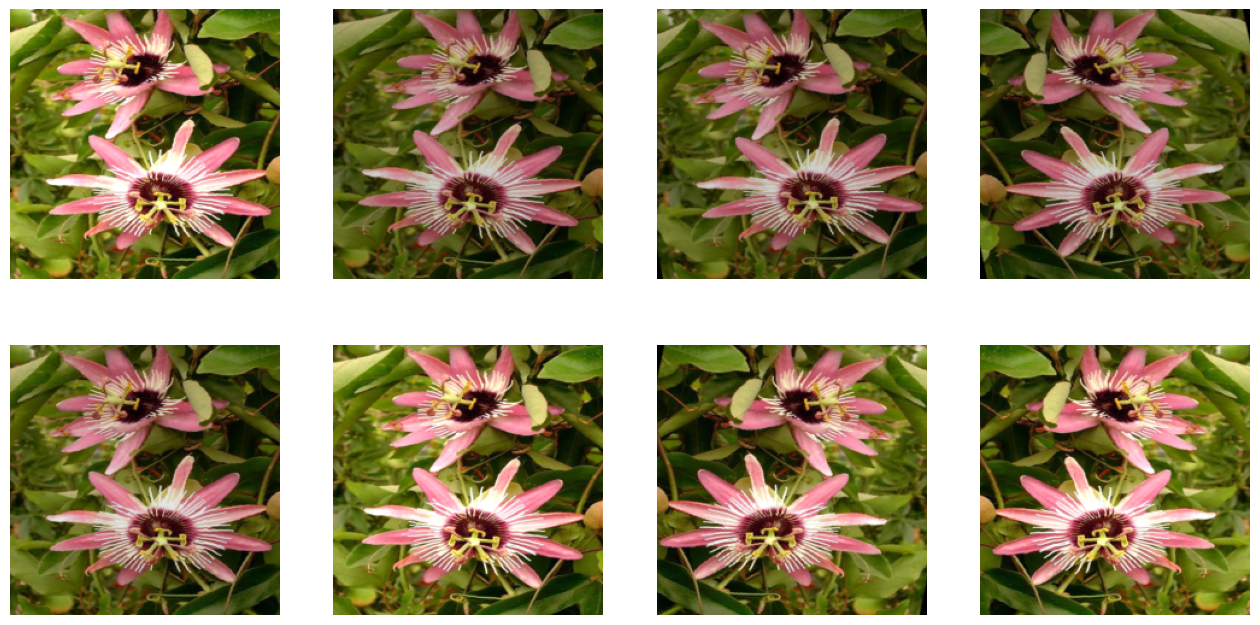

In [34]:
# Exibe 8 versões aumentadas da imagem selecionada para visualizar as transformações.
visualize_augmentations(dataset_augmented, idx=sel_idx, num_versions=8)

### Dividindo com Aumento de Dados (*Augmentation*)

Agora que você verificou o pipeline de aumento de dados, pode aplicá-lo especificamente ao subconjunto de treinamento. Como você já dividiu o conjunto de dados bruto e envolveu cada subconjunto com o `SubsetWithTransform` anteriormente, você só precisa envolver novamente o subconjunto de treinamento com a transformação de aumento de dados. Os subconjuntos de validação e teste permanecem inalterados com a transformação de pré-processamento padrão.

In [35]:
# Agora aplica o pipeline específico de aumento de dados (augmentation) ao subconjunto de treino
# Os subconjuntos de validação e teste permanecem com a transformação de pré-processamento base aplicada anteriormente
train_dataset = SubsetWithTransform(train_subset, transform=augmentation_transform)

Você pode verificar que o conjunto de dados de treinamento possui as transformações de aumento de dados aplicadas, enquanto os conjuntos de validação e teste não as possuem.

In [36]:
# Exibe as transformações (pipeline) aplicadas ao dataset de treino
print(train_dataset.transform)

# Exibe as transformações (pipeline) aplicadas ao dataset de validação
print(val_dataset.transform)

# Exibe as transformações (pipeline) aplicadas ao dataset de teste
print(test_dataset.transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Conjuntos de Dados Robustos (*Robust Datasets*)

Em projetos do mundo real, os pipelines de dados devem ser resilientes a problemas inesperados, como arquivos corrompidos, formatos de imagem inconsistentes ou amostras problemáticas que podem interromper a execução do treinamento. Nesta seção, serão apresentadas estratégias para o design de conjuntos de dados robustos.

### Tratamento de Erros (*Error Handling*)

Você criará uma nova classe *dataset* personalizada chamada `RobustFlowerDataset` que estende a classe `FlowerDataset` original para lidar com potenciais problemas de imagens corrompidas ou problemáticas.

Os métodos `__init__`, `__len__` e `load_and_correct_labels` permanecem essencialmente os mesmos da classe `FlowerDataset` original.

As principais diferenças são:

> `__getitem__`: Implementa um bloco *try-except* para capturar exceções que possam ocorrer ao carregar uma imagem.
> * Se ocorrer uma exceção (por exemplo, devido a um arquivo de imagem corrompido), o código imprimirá e registrará o erro chamando o método `log_error`.
> * Em seguida, ele tentará recuperar a próxima imagem do conjunto de dados em vez de interromper a execução.
> 
> 

> `retrieve_image`: Lida com o processo real de carregamento da imagem.
> * Constrói o nome do arquivo e o caminho, verifica a integridade da imagem usando o método `verify()` da biblioteca Pillow e recarrega a imagem para garantir que ela esteja totalmente carregada na memória.
> * Verifica o tamanho da imagem, gerando um erro se ela for menor que 32 pixels em qualquer uma das dimensões, e converte imagens em tons de cinza (*grayscale*) para RGB para fins de consistência.
> 
> 

> `get_error_summary`: Fornece um resumo de todos os erros encontrados durante o carregamento de dados, o que é útil para depuração e para avaliar a qualidade do conjunto de dados.

In [37]:
class RobustFlowerDataset(Dataset):
    """
    Uma classe de dataset personalizada com tratamento robusto de erros para o carregamento de imagens.

    Esta classe foi projetada para lidar de forma elegante com problemas em amostras de dados individuais,
    como arquivos corrompidos ou formatos incorretos. Ela registra quaisquer erros e tenta carregar
    uma amostra diferente em vez de falhar a execução.
    """
    def __init__(self, root_dir, transform=None):
        """
        Inicializa o objeto do dataset.

        Args:
            root_dir (str): O diretório raiz onde o dataset está armazenado.
            transform (callable, opcional): Transformação opcional a ser aplicada
                em uma amostra.
        """
        # Armazena o caminho do diretório raiz.
        self.root_dir = root_dir
        # Constrói o caminho completo para o diretório de imagens.
        self.img_dir = os.path.join(root_dir, "jpg")
        # Armazena as transformações opcionais.
        self.transform = transform
        # Carrega e processa os rótulos a partir do arquivo correspondente.
        self.labels = self.load_and_correct_labels()
        # Inicializa uma lista para rastrear quaisquer erros encontrados.
        self.error_logs = []

    def __getitem__(self, idx):
        """
        Recupera uma amostra, lidando com erros ao tentar o próximo item disponível.

        Args:
            idx (int): O índice da amostra a ser recuperada.

        Returns:
            image (PIL.Image.Image ou torch.Tensor): Os dados da imagem processada.
            label (int): O rótulo correspondente para a imagem.
        """
        # Loop para tentar carregar uma amostra válida, prevenindo um loop infinito.
        for attempt in range(len(self)):
            # Tenta carregar e processar a amostra.
            try:
                # Recupera a imagem usando o método auxiliar.
                image = self.retrieve_image(idx)
                # Verifica se uma transformação foi fornecida.
                if self.transform:
                    # Aplica a transformação à imagem.
                    image = self.transform(image)
                # Obtém o rótulo para o índice atual.
                label = self.labels[idx]
                # Retorna a imagem válida e seu respectivo rótulo.
                return image, label
            # Captura qualquer exceção que ocorra durante o processo.
            except Exception as e:
                # Registra o erro com seu índice e mensagem.
                self.log_error(idx, e)
                # Move para o próximo índice, reiniciando no zero se necessário (wrapping around).
                idx = (idx + 1) % len(self)

    def __len__(self):
        """
        Retorna o número total de amostras no dataset.

        Returns:
            total_samples (int): O número total de itens no dataset.
        """
        # O número total de amostras é o número de rótulos.
        total_samples = len(self.labels)
        # Retorna o comprimento calculado.
        return total_samples

    def retrieve_image(self, idx):
        """
        Carrega e valida uma única imagem do disco.

        Args:
            idx (int): O índice da imagem a ser carregada.

        Returns:
            image (PIL.Image.Image): O objeto de imagem validado e carregado.
        """
        # Constrói o nome do arquivo da imagem com base no índice.
        img_name = f"image_{idx+1:05d}.jpg"
        # Constrói o caminho completo para o arquivo da imagem.
        img_path = os.path.join(self.img_dir, img_name)
        # Abre o arquivo da imagem para verificar sua integridade sem carregá-la completamente.
        with Image.open(img_path) as img:
            # Realiza uma verificação rápida da estrutura do arquivo.
            img.verify()
        # Reabre o arquivo da imagem após uma verificação bem-sucedida.
        image = Image.open(img_path)
        # Carrega completamente os dados da imagem na memória.
        image.load()
        # Verifica se as dimensões da imagem estão abaixo de um limite mínimo.
        if image.size[0] < 32 or image.size[1] < 32:
            # Levanta um erro para imagens que são muito pequenas.
            raise ValueError(f"Imagem muito pequena: {image.size}")
        # Verifica se a imagem não está no modo de cor RGB.
        if image.mode != "RGB":
            # Converte a imagem para RGB.
            image = image.convert("RGB")
        # Retorna a imagem totalmente carregada e validada.
        return image

    def load_and_correct_labels(self):
        """
        Carrega os rótulos de um arquivo e os ajusta.

        Returns:
            labels (numpy.ndarray): Um array de rótulos inteiros com indexação baseada em zero.
        """
        # Carrega o arquivo contendo os rótulos.
        self.labels_mat = scipy.io.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extrai o array de rótulos e corrige para a indexação baseada em zero.
        labels = self.labels_mat["labels"][0] - 1
        # Trunca o dataset para os primeiros 10 rótulos para testes rápidos.
        labels = labels[:10]
        # Retorna os rótulos processados.
        return labels

    def log_error(self, idx, e):
        """
        Registra os detalhes de um erro encontrado durante o carregamento dos dados.

        Args:
            idx (int): O índice da amostra problemática.
            e (Exception): O objeto de exceção que foi levantado.
        """
        # Constrói o nome do arquivo da imagem problemática.
        img_name = f"image_{idx + 1:05d}.jpg"
        # Constrói o caminho completo para o arquivo da imagem.
        img_path = os.path.join(self.img_dir, img_name)
        # Adiciona um dicionário com os detalhes do erro ao log.
        self.error_logs.append(
            {
                "index": idx,
                "error": str(e),
                "path": img_path if "img_path" in locals() else "unknown",
            }
        )
        # Imprime um aviso no console sobre a imagem ignorada.
        print(f"Aviso: Ignorando imagem corrompida {idx}: {e}")

    def get_error_summary(self):
        """
        Imprime um resumo de todos os erros encontrados durante o processamento do dataset.
        """
        # Verifica se o log de erros está vazio.
        if not self.error_logs:
            # Imprime uma mensagem indicando que o dataset está limpo.
            print("Nenhum erro encontrado - o dataset está limpo!")
        else:
            # Imprime o número total de imagens problemáticas encontradas.
            print(f"\nEncontradas {len(self.error_logs)} imagens problemáticas:")
            # Itera através dos primeiros erros registrados.
            for error in self.error_logs[:5]:
                # Imprime os detalhes de um erro individual.
                print(f"  Índice {error['index']}: {error['error']}")
            # Verifica se há mais erros do que os exibidos.
            if len(self.error_logs) > 5:
                # Imprime um resumo dos erros restantes.
                print(f"  ... e mais {len(self.error_logs) - 5}")

O conjunto de dados *Oxford Flowers 102* é limpo, mas, para ilustrar as técnicas de robustez, um subconjunto de imagens no conjunto de dados foi intencionalmente corrompido. Os arquivos desse subconjunto estão na pasta `./corrupted_flower_data`.

Você pode criar uma instância da classe `RobustFlowerDataset` passando o caminho para o conjunto de dados corrompido.

In [38]:
# Define o caminho para o diretório que contém o dataset corrompido.
corrupted_dataset_path = './corrupted_flower_data'

# Inicializa o manipulador de dataset robusto com o caminho para os dados corrompidos.
robust_dataset = RobustFlowerDataset(corrupted_dataset_path)

Aviso: Ignorando imagem corrompida 2: Imagem muito pequena: (20, 20)


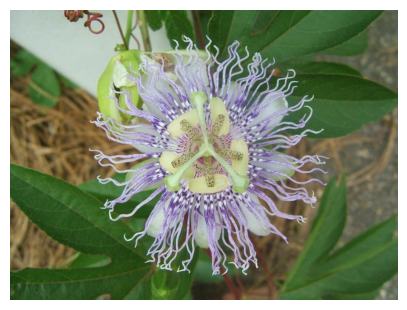

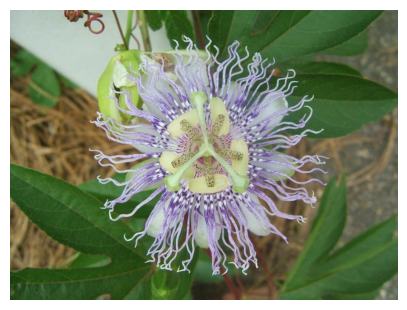

In [39]:
# Define o índice para uma imagem sabidamente corrompida. A imagem 2 é muito pequena
idx = 2

# Tenta recuperar a imagem; o dataset robusto irá pular a corrompida e retornar a próxima.
img, label = robust_dataset[idx]

# Plota a imagem recuperada, que deve ser a seguinte àquela que estava corrompida.
helper_utils_5.plot_img(img)

# Recupera explicitamente a próxima imagem na sequência para verificação.
next_img, next_label = robust_dataset[idx + 1]

# Plota a próxima imagem; ela deve ser idêntica à de cima.
helper_utils_5.plot_img(next_img)

In [40]:
# Define o índice para uma imagem sabidamente em tons de cinza.
# A imagem 4 está corrompida (tons de cinza)
idx = 4

# Reconstrói o caminho para o arquivo de imagem original.
original_img_path = os.path.join(robust_dataset.img_dir, f"image_{idx + 1:05d}.jpg")
# Abre a imagem original diretamente para verificar seu modo antes da correção.
original_img = Image.open(original_img_path)
# Imprime o modo da imagem original, não corrigida.
# Imprime 'L' para tons de cinza de 8 bits. Uma imagem colorida padrão seria 'RGB'.
print(f"Modo do arquivo de imagem original: {original_img.mode}")

Modo do arquivo de imagem original: L


Modo da imagem corrigida: RGB


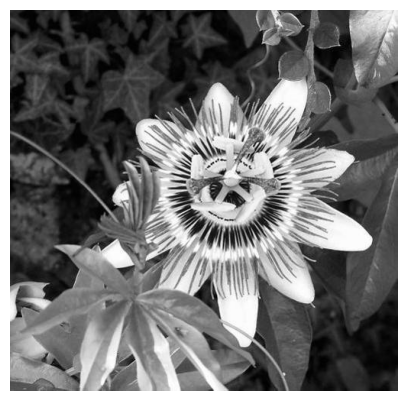

In [41]:
# Recupera a imagem; o carregador robusto deve convertê-la automaticamente para RGB.
img, label = robust_dataset[idx]

# Plota a imagem para confirmar visualmente que agora ela está em cores.
helper_utils_5.plot_img(img)

# Imprime o modo da imagem para confirmar que foi corrigido para 'RGB'.
print(f"Modo da imagem corrigida: {img.mode}")

Aviso: Ignorando imagem corrompida 6: cannot identify image file './corrupted_flower_data/jpg/image_00007.jpg'


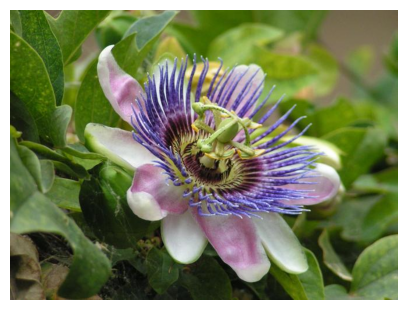

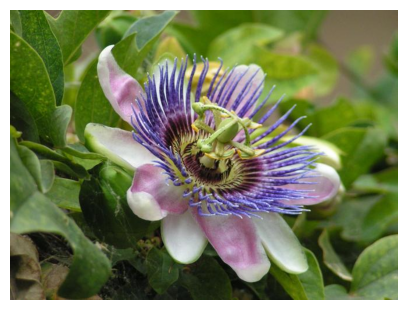

In [42]:
# Define o índice para uma imagem sabidamente corrompida ou ilegível.
idx = 6

# Tenta recuperar a imagem; o carregador robusto deve pular o arquivo corrompido e retornar o próximo.
robust_img = robust_dataset[idx][0]

# Plota a imagem recuperada, que deve ser a amostra do próximo índice (7).
helper_utils_5.plot_img(robust_img)

# Recupera explicitamente a próxima imagem na sequência para verificar a lógica de fallback (alternativa).
# Verifica a próxima imagem para garantir que está correta.
next_img, next_label = robust_dataset[idx + 1]

# Plota a próxima imagem; ela deve ser idêntica à de cima, confirmando que o arquivo corrompido foi pulado.
helper_utils_5.plot_img(next_img)

Você pode ver que as imagens 2, 4 e 6 estão corrompidas de maneiras diferentes, mas a classe *dataset* robusta é capaz de lidar com esses casos adequadamente.

Você pode obter um resumo dos erros encontrados durante o carregamento dos dados inspecionando o atributo `error_logs`.

In [43]:
# Exibe o resumo de quaisquer imagens corrompidas ou problemáticas encontradas durante o carregamento.
robust_dataset.get_error_summary()


Encontradas 2 imagens problemáticas:
  Índice 2: Imagem muito pequena: (20, 20)
  Índice 6: cannot identify image file './corrupted_flower_data/jpg/image_00007.jpg'


### Rastreamento de Erros (*Tracking Errors*)

Em projetos de *deep learning* do mundo real, os pipelines de dados precisam ser robustos não apenas contra arquivos corrompidos, mas também contra problemas sutis que podem degradar silenciosamente o desempenho do modelo. Além de tratar exceções, é importante rastrear e analisar sistematicamente os erros e anomalias que ocorrem durante o carregamento de dados e o pré-processamento.

Esta seção final introduz estratégias práticas para o rastreamento de erros dentro do seu pipeline de conjunto de dados. Você aprenderá a registrar amostras problemáticas, monitorar quais imagens são acessadas (e com que frequência) e revisar resumos de erros após o treinamento. Essas técnicas ajudam a garantir que seu pipeline seja resiliente, transparente e pronto para produção, permitindo detectar e resolver problemas de qualidade de dados antes que eles afetem os resultados do seu modelo.

A classe `MonitoredDataset` estende a `RobustFlowerDataset` para adicionar recursos de monitoramento ao acesso do conjunto de dados e ao desempenho de carregamento.

* **Rastreamento de Acesso**: Cada vez que uma imagem é carregada por meio de `__getitem__`, a classe incrementa um contador para o índice daquela imagem em `self.access_counts`. Isso permite rastrear com que frequência cada amostra é acessada durante o treinamento ou avaliação.
* **Medição do Tempo de Carregamento**: Esta classe registra o tempo gasto para carregar cada imagem e armazena esses valores em `self.load_times`. Se o carregamento de uma imagem demorar mais de 1 segundo, um aviso é exibido com o índice da imagem e o tempo de carregamento. Isso ajuda a identificar amostras de carregamento lento que podem afetar o desempenho do treinamento.
* **Relatório de Estatísticas**: O método `print_stats()` fornece um resumo do uso do conjunto de dados, incluindo:
* Número total de imagens no conjunto de dados
* Número de imagens únicas que foram acessadas
* Número de erros encontrados (herdado da classe pai)
* Tempos médio e máximo de carregamento de imagens
* Um aviso com exemplos caso alguma imagem nunca tenha sido acessada



Essas capacidades de monitoramento ajudam você a identificar gargalos, diagnosticar erros e garantir a confiabilidade do seu pipeline de dados, tornando mais fácil depurar e otimizar a manipulação de conjuntos de dados em fluxos de trabalho de *deep learning*.

In [44]:
class MonitoredDataset(RobustFlowerDataset):
    """
    Estende uma classe de dataset robusta para adicionar monitoramento de desempenho.

    Esta classe rastreia métricas como a frequência com que cada imagem é acessada,
    o tempo que cada acesso leva e quais imagens nunca são carregadas. Ela fornece
    um resumo dessas estatísticas para ajudar a diagnosticar problemas no pipeline de dados.
    """
    def __init__(self, *args, **kwargs):
        """
        Inicializa o objeto do dataset monitorado.

        Args:
            *args (tuple): Lista de argumentos de tamanho variável passados para a classe pai.
            **kwargs (dict): Argumentos nomeados arbitrários passados para a classe pai.
        """
        # Inicializa a classe pai com todos os argumentos fornecidos.
        super().__init__(*args, **kwargs)
        # Inicializa um dicionário para contar quantas vezes cada índice é acessado.
        self.access_counts = {}
        # Inicializa uma lista para armazenar o tempo de carregamento de cada acesso.
        self.load_times = []

    def __getitem__(self, idx):
        """
        Recupera uma amostra enquanto monitora as contagens de acesso e os tempos de carregamento.

        Args:
            idx (int): O índice da amostra a ser recuperada.

        Returns:
            result (tuple): A amostra de dados (por exemplo, imagem e rótulo) da classe pai.
        """
        # Importa o módulo time para operações de cronometragem.
        import time
        # Registra o tempo de início da operação.
        start_time = time.time()
        # Incrementa a contagem de acesso para o índice fornecido.
        self.access_counts[idx] = self.access_counts.get(idx, 0) + 1
        # Chama o método da classe pai para carregar os dados.
        result = super().__getitem__(idx)
        # Calcula o tempo total levado para carregar a amostra.
        load_time = time.time() - start_time
        # Adiciona o tempo de carregamento calculado à lista.
        self.load_times.append(load_time)
        # Verifica se o tempo de carregamento excede um certo limite.
        if load_time > 1.0:
            # Imprime um aviso se um tempo de carregamento lento for detectado.
            print(f"⚠️ Carregamento lento: Imagem {idx} levou {load_time:.2f}s")
        # Retorna a amostra carregada da classe pai.
        return result

    def print_stats(self):
        """
        Imprime um resumo das estatísticas de acesso e do desempenho do dataset.
        """
        # Imprime um cabeçalho para o relatório de estatísticas.
        print("\n=== Estatísticas do Pipeline ===")
        # Exibe o número total de imagens no dataset.
        print(f"Total de imagens: {len(self)}")
        # Exibe o número de imagens únicas que foram acessadas.
        print(f"Imagens únicas acessadas: {len(self.access_counts)}")
        # Exibe o número total de erros registrados pela classe pai.
        print(f"Erros encontrados: {len(self.error_logs)}")
        # Verifica se algum tempo de carregamento foi registrado.
        if self.load_times:
            # Calcula o tempo médio de carregamento.
            avg_time = sum(self.load_times) / len(self.load_times)
            # Encontra o tempo máximo (mais lento) de carregamento.
            max_time = max(self.load_times)
            # Imprime o tempo médio de carregamento em milissegundos.
            print(f"Tempo médio de carregamento: {avg_time*1000:.1f} ms")
            # Imprime o tempo de carregamento mais lento em milissegundos.
            print(f"Carregamento mais lento: {max_time*1000:.1f} ms")
        # Cria um conjunto (set) de todos os índices possíveis no dataset.
        all_indices = set(range(len(self)))
        # Cria um conjunto de todos os índices que foram de fato acessados.
        accessed_indices = set(self.access_counts.keys())
        # Encontra o conjunto de índices que nunca foram acessados.
        never_accessed = all_indices - accessed_indices
        # Verifica se há imagens que nunca foram carregadas.
        if never_accessed:
            # Imprime uma mensagem de aviso com a contagem de imagens nunca acessadas.
            print(f"\n⚠️ AVISO: {len(never_accessed)} imagens nunca foram carregadas!")
            # Mostra alguns exemplos dos índices que nunca foram acessados.
            print(f"   Exemplos: {list(never_accessed)[:5]}")

In [45]:
# Inicializa o dataset monitorado com o caminho para os dados potencialmente corrompidos.
monitored_dataset = MonitoredDataset(corrupted_dataset_path)

# Percorre cada índice no dataset para simular uma passagem completa.
# Itera pelo dataset para acionar o monitoramento.
for idx in range(len(monitored_dataset)):
    # Acessa a amostra no índice atual para acionar a lógica de monitoramento e tratamento de erros.
    img, label = monitored_dataset[idx]

Aviso: Ignorando imagem corrompida 2: Imagem muito pequena: (20, 20)
Aviso: Ignorando imagem corrompida 6: cannot identify image file './corrupted_flower_data/jpg/image_00007.jpg'


In [46]:
# Imprime as estatísticas de acesso e desempenho do dataset
monitored_dataset.print_stats()


=== Estatísticas do Pipeline ===
Total de imagens: 10
Imagens únicas acessadas: 10
Erros encontrados: 2
Tempo médio de carregamento: 2.7 ms
Carregamento mais lento: 3.5 ms


O método `print_stats` fornece uma visão geral abrangente do uso do conjunto de dados e de quaisquer problemas encontrados durante o carregamento de dados.

Esta é uma boa prática para se implementar em suas classes *dataset*, pois ajuda a monitorar a qualidade dos seus dados e o desempenho do seu pipeline de dados.

## Conclusão

Você construiu um pipeline de dados completo e pronto para produção no PyTorch.
Neste laboratório, você foi além do trabalho com dados perfeitamente organizados e aprendeu a gerenciar as complexidades do mundo real na manipulação de dados, desde o acesso inicial até o agrupamento eficiente em lotes (*batching*).

Você viu como organizar um conjunto de dados desordenado criando uma classe **`Dataset`** personalizada para carregar imagens e rótulos de arquivos separados. Você aplicou etapas essenciais de pré-processamento, incluindo **transformações** para normalizar seus dados e **aumento de dados** para tornar seu futuro modelo mais robusto.

Em seguida, você usou o **`DataLoader`** para preparar seus dados, agrupando-os em lotes e embaralhando-os para o treinamento. Finalmente, você tornou seu pipeline mais confiável ao implementar o tratamento de erros e o monitoramento de desempenho, garantindo que o processo de treinamento do seu modelo seja estável e eficiente.

Você construiu uma base sólida em gerenciamento de dados que dará suporte a tudo o que você fizer a seguir.